# Notebook 02 — specparam fitting: iEEG (Frauscher 2018)

Fits aperiodic and oscillatory parameters on the intracranial EEG atlas data.
Uses the modern `specparam >= 2.0.0rc6` API (`SpectralGroupModel`).

**Outputs** saved to `data/interim/`:
- `specparam_ieeg_results.csv` — channel-level results (exponent, offset, peaks, fit quality)

**Note on PSDs**: The existing `power.csv` uses a normalized amplitude spectrum  
(sqrt(PSD) / total-amplitude) which would halve the estimated exponent and distort  
the offset. This notebook recomputes raw Welch PSDs from the MATLAB source file.

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import scipy.io
import h5py
from scipy.signal import welch
import matplotlib.pyplot as plt
import specparam
from specparam import SpectralGroupModel
from specparam.plts.spectra import plot_spectra
from pesco.spectral import inspect_fit_quality, inspect_fits, specparam2pandas

# Add project root to path for pesco imports
#sys.path.insert(0, str(PROJECT_ROOT))
print(specparam.__version__)

2.0.0rc6


In [3]:
PROJECT_ROOT = Path("../../").resolve()
print(f"Project root: {PROJECT_ROOT}")
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR       = PROJECT_ROOT / "data"
IEEG_MAT       = DATA_DIR / "Frauscher2018" / "WakefulnessMatlabFile.mat"
CHANNEL_INFO   = DATA_DIR / "Frauscher2018" / "ChannelInformation.csv"
REGION_INFO    = DATA_DIR / "Frauscher2018" / "RegionInformation.csv"
INTERIM_DIR    = DATA_DIR / "interim"
INTERIM_DIR.mkdir(exist_ok=True)

FS = 200.0   # Hz — sampling frequency of Frauscher 2018 dataset
R2_THRESHOLD = 0.90   # chapter standard (Donoghue et al. 2021 recommendation)

Project root: /Users/daniel/PhD/spectral-comparison/code


## 1. Load iEEG data

The MATLAB file may be saved in v7.3 (HDF5) format. We try `scipy.io.loadmat`
first and fall back to `h5py` if needed.

In [4]:
print(f"Loading {IEEG_MAT.name} …")

try:
    mat = scipy.io.loadmat(str(IEEG_MAT))
    data   = mat["Data"].T                          # (n_channels, n_samples)
    Fs     = float(np.array(mat["SamplingFrequency"]).flatten()[0])
    ch_regions = np.array(mat["ChannelRegion"]).flatten()
    ch_names   = [str(x[0][0]) for x in mat["ChannelName"]]
    print("Loaded via scipy.io.loadmat")

except Exception as e:
    print(f"scipy.io failed ({e}), trying h5py …")
    with h5py.File(IEEG_MAT, "r") as f:
        data         = np.array(f["Data"]).T          # (n_channels, n_samples)
        Fs           = float(np.array(f["SamplingFrequency"]).flatten()[0])
        ch_regions   = np.array(f["ChannelRegion"]).flatten()
        # Channel names are stored as HDF5 object references
        ch_names_refs = np.array(f["ChannelName"]).flatten()
        ch_names = [
            "".join(chr(c) for c in np.array(f[ref]).flatten())
            for ref in ch_names_refs
        ]
    print("Loaded via h5py")

print(f"Data shape: {data.shape}  |  Fs: {Fs} Hz  |  Channels: {len(ch_names)}")
print(f"Duration: {data.shape[1] / Fs:.1f} s")

Loading WakefulnessMatlabFile.mat …
Loaded via scipy.io.loadmat
Data shape: (1772, 13600)  |  Fs: 200.0 Hz  |  Channels: 1772
Duration: 68.0 s


## 2. Compute power spectral densities

Using Welch's method with 2 s segments and 1 s overlap — matching the original  
Frauscher 2018 spectral estimation. Scaling = 'density' gives V²/Hz units,  
suitable for specparam.

In [ ]:
nperseg  = int(2 * FS)
noverlap = int(FS)

SPECPARAM_SETTINGS = {
    "freq_range": (2.0, 100.0),        # Hz — original run (kept for continuity)
    "aperiodic_mode": "fixed",         # no knee
    "peak_width_limits": [1.0, 12.0],
    "max_n_peaks": 6,
    "min_peak_height": 0.05,
    "peak_threshold": 2.0,
    "r2_threshold": 0.90,              # chapter standard
}

freqs, psds = welch(
    data, fs=FS, nperseg=nperseg, noverlap=noverlap,
    detrend="constant", scaling="density"
)

print(f"PSD shape: {psds.shape}")
print(f"Frequency resolution: {freqs[1] - freqs[0]:.3f} Hz")
print(f"Frequency range: {freqs[0]:.1f} - {freqs[-1]:.1f} Hz")

# Sanity check: plot median spectrum
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(freqs, np.median(psds, axis=0))
ax.set_xlim(1, 80)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD (V²/Hz)")
ax.set_title("Median PSD across all iEEG channels")
ax.axvspan(SPECPARAM_SETTINGS["freq_range"][0], SPECPARAM_SETTINGS["freq_range"][1], alpha=0.1, color="green", label="fitting range")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Specparam helper: `specparam2pandas`

Converts a fitted `SpectralGroupModel` to a tidy long-format DataFrame.  
One row per peak; channels with no peaks retain NaN peak columns.

## 4. Fit SpectralGroupModel

https://specparam-tools.github.io/

{'freq_range': (2.0, 100.0),
 'aperiodic_mode': 'fixed',
 'peak_width_limits': [1.0, 12.0],
 'max_n_peaks': 6,
 'min_peak_height': 0.05,
 'peak_threshold': 2.0,
 'r2_threshold': 0.8}
Fitting 1772 spectra in range (2.0, 100.0) Hz ...
Fitting model across 1772 power spectra.
Done.
                                                                                                  
                           GROUP SPECTRAL MODEL RESULTS (1772 spectra)                            
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
              Model was fit to the 2-100 Hz frequency range with 0.50 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                         of

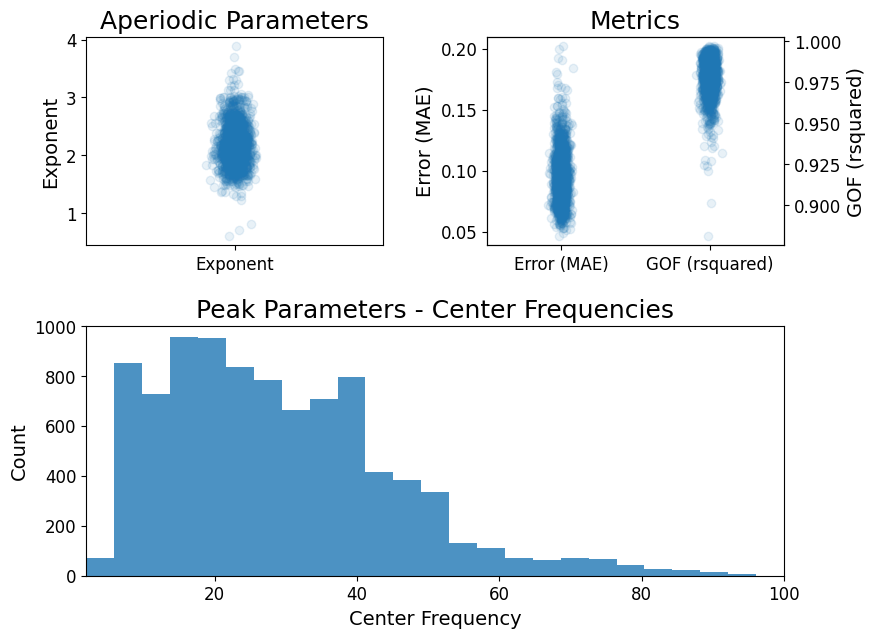

In [6]:
#print(SPECPARAM_SETTINGS)
from pprint import pprint
pprint(SPECPARAM_SETTINGS, sort_dicts=False)

fg = SpectralGroupModel(
peak_width_limits=SPECPARAM_SETTINGS["peak_width_limits"],
max_n_peaks=SPECPARAM_SETTINGS["max_n_peaks"],
min_peak_height=SPECPARAM_SETTINGS["min_peak_height"],
peak_threshold=SPECPARAM_SETTINGS["peak_threshold"],
aperiodic_mode=SPECPARAM_SETTINGS["aperiodic_mode"],
)

print(f"Fitting {psds.shape[0]} spectra in range {SPECPARAM_SETTINGS['freq_range']} Hz ...")
# Note: n_jobs=-1 causes metrics (MAE, R²) to be NaN in specparam 2.0.0rc6 due to a
# parallelisation bug where metrics aren't returned from workers. Use n_jobs=1.
fg.fit(freqs, psds, freq_range=SPECPARAM_SETTINGS["freq_range"], n_jobs=1)
print("Done.")

fg.print_results()
fg.plot(n_cols=4, plot_peaks="shade", plot_aperiodic=False)


## 5. QC: inspect fit quality

In [7]:
results_df = specparam2pandas(fg)
results_df


,ID,offset,exponent,error_mae,gof_rsquared,CF,PW,BW
0,0,1.890655,1.997513,0.092839,0.982486,14.766429,1.181235,7.737114
1,0,1.890655,1.997513,0.092839,0.982486,26.133872,0.737923,11.650777
2,0,1.890655,1.997513,0.092839,0.982486,40.138660,0.546340,12.000000
3,0,1.890655,1.997513,0.092839,0.982486,59.622906,0.287451,11.999996
4,1,1.971762,1.946421,0.114155,0.972484,15.158419,1.034573,7.184870
...,...,...,...,...,...,...,...,...
9093,1771,3.070432,1.832233,0.089844,0.976028,10.402957,0.553470,4.582816
9094,1771,3.070432,1.832233,0.089844,0.976028,17.275410,0.622797,8.642468
9095,1771,3.070432,1.832233,0.089844,0.976028,24.014038,0.697024,1.830341
9096,1771,3.070432,1.832233,0.089844,0.976028,30.543691,0.532041,12.000000


Fit quality summary:
       error_mae  gof_rsquared  exponent
count   1772.000      1772.000  1772.000
mean       0.095         0.979     2.172
std        0.021         0.011     0.349
min        0.047         0.881     0.611
25%        0.080         0.973     1.937
50%        0.093         0.980     2.143
75%        0.108         0.987     2.379
max        0.202         0.997     3.885

Channels with R² ≥ 0.8: 1772 / 1772 (100.0%)


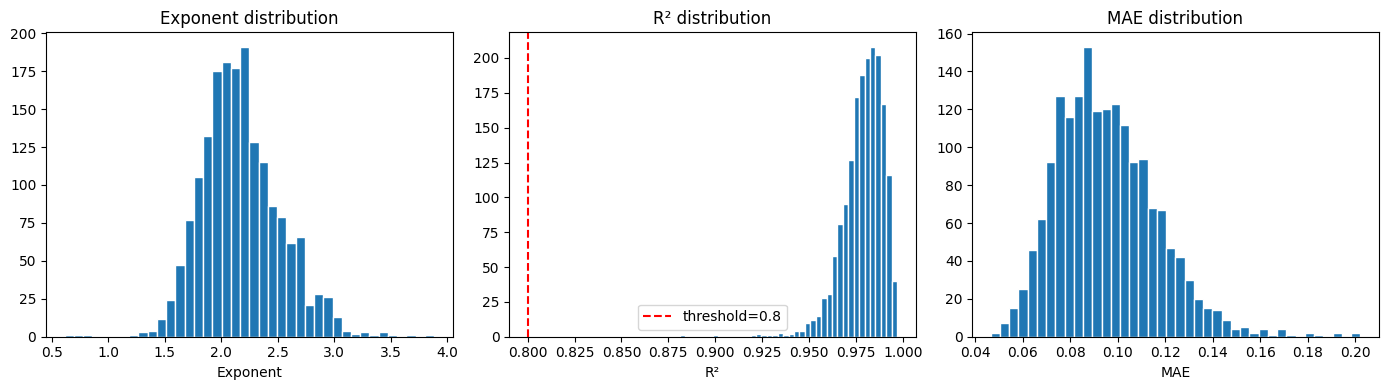

In [12]:
ch_df, summary_df, fig, axes = inspect_fit_quality(
    results_df, r2_threshold=R2_THRESHOLD, bins=40, show=True
)


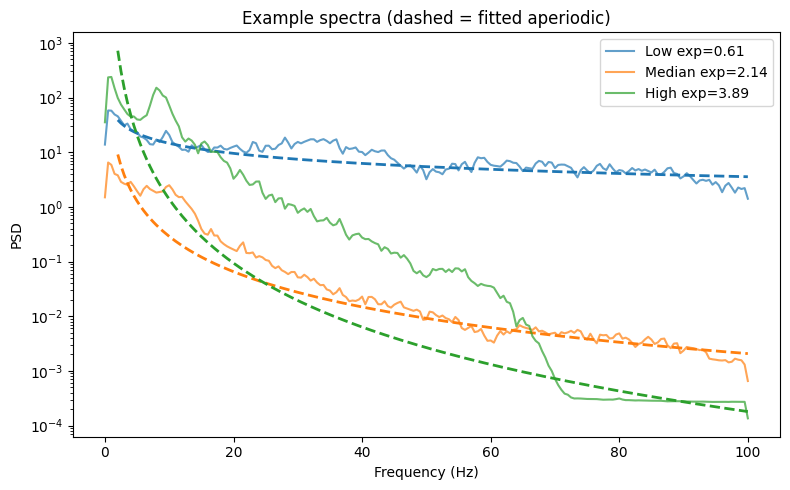

In [16]:
figure, ax = inspect_fits(fg, psds, freqs)

## 6. Attach channel and region metadata

In [13]:
# Channel metadata from ChannelInformation.csv
ch_info = pd.read_csv(CHANNEL_INFO)
ch_info.columns = ch_info.columns.str.strip()
# Strip quotes from string columns
for col in ch_info.select_dtypes("object").columns:
    ch_info[col] = ch_info[col].str.strip("'")

# Region labels: from MATLAB data
ch_region_df = pd.DataFrame({
    "ch_name": ch_names,
    "Region":  ch_regions.astype(int),
})

# Region names from RegionInformation.csv
region_info = pd.read_csv(REGION_INFO)
region_info.columns = region_info.columns.str.strip()
for col in region_info.select_dtypes("object").columns:
    region_info[col] = region_info[col].str.strip("'")

# Merge region names onto channel list
ch_meta = ch_region_df.merge(region_info, on="Region", how="left")
# Also merge channel-level info (patient, hemisphere, coordinates)
ch_meta = ch_meta.merge(
    ch_info.rename(columns={"Channel name": "ch_name"}),
    on="ch_name", how="left"
)
ch_meta["ID"] = range(len(ch_meta))

# Attach to results
results_full = results_df.merge(ch_meta, on="ID", how="left")
results_full["good_fit"] = results_full["gof_rsquared"] >= R2_THRESHOLD

print(results_full.shape)
results_full.head(3)

(9098, 20)


,ID,offset,exponent,error_mae,gof_rsquared,CF,PW,BW,ch_name,Region_x,Region name,Lobe,Electrode type,Patient,Hemisphere,Region_y,x,y,z,good_fit
0,0,1.890655,1.997513,0.092839,0.982486,14.766429,1.181235,7.737114,GD001Lc_11,31,Middle temporal gyrus,Temporal,D,1.0,L,31.0,60.127504,-34.113299,-3.886026,True
1,0,1.890655,1.997513,0.092839,0.982486,26.133872,0.737923,11.650777,GD001Lc_11,31,Middle temporal gyrus,Temporal,D,1.0,L,31.0,60.127504,-34.113299,-3.886026,True
2,0,1.890655,1.997513,0.092839,0.982486,40.138660,0.546340,12.000000,GD001Lc_11,31,Middle temporal gyrus,Temporal,D,1.0,L,31.0,60.127504,-34.113299,-3.886026,True


## 7. Save results

In [14]:
out_path = INTERIM_DIR / "specparam_ieeg_results.csv"
results_full.to_csv(out_path, index=False)
print(f"Saved {len(results_full)} rows → {out_path}")

# Also save a per-channel summary (no repeated peak rows)
ch_summary = results_full.drop_duplicates(subset="ID").drop(columns=["CF", "PW", "BW"], errors="ignore")
ch_summary.to_csv(INTERIM_DIR / "specparam_ieeg_ch_summary.csv", index=False)
print(f"Saved channel summary → {INTERIM_DIR / 'specparam_ieeg_ch_summary.csv'}")

# Quick count by lobe
if "Lobe" in ch_summary.columns:
    print("\nGood fits by lobe:")
    print(ch_summary[ch_summary["good_fit"]].groupby("Lobe")["exponent"].agg(["count", "median"]).round(3))

Saved 9098 rows → /Users/daniel/PhD/spectral-comparison/data/interim/specparam_ieeg_results.csv
Saved channel summary → /Users/daniel/PhD/spectral-comparison/data/interim/specparam_ieeg_ch_summary.csv

Good fits by lobe:
           count  median
Lobe                    
Frontal      797   2.072
Insula       106   2.178
Occipital    104   2.344
Parietal     353   2.114
Temporal     412   2.239


## 8. Second fit: 1–40 Hz (chapter canonical range)

Re-run specparam over 1–40 Hz to match the IRASA fitting range and the chapter Methods.
Results saved with `_1_40hz` suffix so both sets are available for comparison.

In [ ]:
FREQ_RANGE_1_40 = (1.0, 40.0)  # chapter Methods: matched to IRASA range

fg_1_40 = SpectralGroupModel(
    peak_width_limits=SPECPARAM_SETTINGS["peak_width_limits"],
    max_n_peaks=SPECPARAM_SETTINGS["max_n_peaks"],
    min_peak_height=SPECPARAM_SETTINGS["min_peak_height"],
    peak_threshold=SPECPARAM_SETTINGS["peak_threshold"],
    aperiodic_mode=SPECPARAM_SETTINGS["aperiodic_mode"],
)

print(f"Fitting {psds.shape[0]} spectra in range {FREQ_RANGE_1_40} Hz …")
fg_1_40.fit(freqs, psds, freq_range=FREQ_RANGE_1_40, n_jobs=1)
print("Done.")

In [ ]:
results_1_40 = specparam2pandas(fg_1_40)
results_1_40_full = results_1_40.merge(ch_meta, on="ID", how="left")
results_1_40_full["good_fit"] = results_1_40_full["gof_rsquared"] >= R2_THRESHOLD

# QC
ch_df_1_40, summary_1_40, _, _ = inspect_fit_quality(
    results_1_40, r2_threshold=R2_THRESHOLD, bins=40, show=True
)

# Save
results_1_40_full.to_csv(INTERIM_DIR / "specparam_ieeg_results_1_40hz.csv", index=False)
ch_summary_1_40 = results_1_40_full.drop_duplicates(subset="ID").drop(columns=["CF", "PW", "BW"], errors="ignore")
ch_summary_1_40.to_csv(INTERIM_DIR / "specparam_ieeg_ch_summary_1_40hz.csv", index=False)
print(f"Saved 1-40 Hz results → {INTERIM_DIR / 'specparam_ieeg_ch_summary_1_40hz.csv'}")

if "Lobe" in ch_summary_1_40.columns:
    print("\nGood fits by lobe (1-40 Hz, R² ≥ 0.90):")
    print(ch_summary_1_40[ch_summary_1_40["good_fit"]].groupby("Lobe")["exponent"].agg(["count", "median"]).round(3))

# Quick comparison: exponent distribution at 2-100 Hz vs 1-40 Hz
ch_orig = results_df.drop_duplicates("ID")
ch_new  = results_1_40.drop_duplicates("ID")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(ch_orig["exponent"].dropna(), bins=40, alpha=0.6, label="2-100 Hz")
axes[0].hist(ch_new["exponent"].dropna(),  bins=40, alpha=0.6, label="1-40 Hz")
axes[0].set_xlabel("Exponent"); axes[0].set_title("Exponent distribution"); axes[0].legend()
axes[1].hist(ch_orig["gof_rsquared"].dropna(), bins=40, alpha=0.6, label="2-100 Hz")
axes[1].hist(ch_new["gof_rsquared"].dropna(),  bins=40, alpha=0.6, label="1-40 Hz")
axes[1].set_xlabel("R²"); axes[1].set_title("R² distribution"); axes[1].legend()
plt.suptitle("Range comparison: 2-100 Hz vs 1-40 Hz")
plt.tight_layout()
plt.show()